## Семинар по uplift рекомендациям

датасет: https://github.com/finn-no/recsys_slates_dataset

в этом датасете есть данные по показам для людей определенных товаров с маркетплейса, причем как с поиска, так и с рекомендаций

## I. Подготовка данных

In [1]:
import numpy as np
import pandas as pd
import json

with open ('../../ind2val.json', 'r') as f:
    cats = json.load(f)

itemattr = np.load('../../itemattr.npz')['category']
a = np.load('../../data.npz')

In [2]:
# Extract the arrays
user_ids = a['userId']  # Array of user IDs
clicks = a['click']  # Array of clicked item IDs
click_indices = a['click_idx']  # Array of indices of clicked items in the slate
slates = a['slate']  # Array of item IDs shown to each user (slates)
interaction_types = a['interaction_type']  # Array of interaction types (2 for search, 1 for recommendation)

In [3]:
a.files

['userId', 'click', 'click_idx', 'slate_lengths', 'slate', 'interaction_type']

In [4]:
from tqdm import tqdm

# Initialize lists to store the final data
user_list = []
item_list = []
interaction_list = []
timestamp_list = []
label_list = []

# Iterate through each user and their corresponding slate, clicks, and interaction type
for i in tqdm(range(len(user_ids))):
    user_id = user_ids[i]
    slate_items = slates[i]  # Item IDs shown to the current user
    clicked_items = clicks[i]  # Item IDs clicked by the current user
    interaction_type = interaction_types[i]  # Interaction type (2 for search, 1 for recommendation)
    #print(len(slate_items))

    # Iterate through each item in the slate
    for j in range(len(slate_items)):

        items_id = slate_items[j]

        for k in range(len(items_id)):

            if items_id[k] == clicked_items[j]:
                label = 1  # Clicked
            else:
                label = 0  # Not clicked
    
            # Append the data to the lists
            user_list.append(user_id)
            item_list.append(items_id[k])
            interaction_list.append(int(interaction_type[j]==2))
            timestamp_list.append(30*i+j)  # Use position in slate as a placeholder for timestamp
            label_list.append(label)

    if i > 1000:
        break

# Create a DataFrame from the lists
df = pd.DataFrame({
    'user_id': user_list,
    'item_id': item_list,
    'is_recommended': interaction_list,
    'timestamp': timestamp_list,
    'label': label_list
})

# Save the DataFrame to a CSV file (optional)
#df.to_csv('output.csv', index=False)

# Display the DataFrame
print(df.head())

  0%|                                  | 1001/2277645 [00:00<34:19, 1105.26it/s]


   user_id  item_id  is_recommended  timestamp  label
0      148        1               1          0      0
1      148   476178               1          0      0
2      148        2               1          0      0
3      148   909795               1          0      0
4      148   926004               1          0      0


In [5]:
cat_mapping = {k: v for k, v in enumerate(itemattr)}
df['category_id'] = df.item_id.apply(lambda x: cat_mapping.get(x, 0))

## II. Генерация фичей

In [6]:
df.head()

,user_id,item_id,is_recommended,timestamp,label,category_id
0,148,1,1,0,0,1.0
1,148,476178,1,0,0,102.0
2,148,2,1,0,0,2.0
3,148,909795,1,0,0,201.0
4,148,926004,1,0,0,204.0


In [7]:
df = df.sort_values(by=['user_id','item_id','timestamp'])

In [8]:
import pandas as pd
from tqdm import tqdm

# Initialize dictionaries to store cumulative statistics
user_item_seen_from_search = {}
user_item_seen_from_recommendation = {}
user_item_taps_from_search = {}
user_item_taps_from_recommendation = {}
user_total_searches = {}
user_total_recommendations = {}
user_total_taps = {}

# New dictionaries for category-related features
user_category_seen_from_search = {}
user_category_seen_from_recommendation = {}
user_category_taps_from_search = {}
user_category_taps_from_recommendation = {}

# Lists to store the new features
user_item_seen_from_search_list = []
user_item_seen_from_recommendation_list = []
user_item_taps_from_search_list = []
user_item_taps_from_recommendation_list = []
user_total_searches_list = []
user_total_recommendations_list = []
user_total_taps_list = []

# New lists for category-related features
user_category_seen_from_search_list = []
user_category_seen_from_recommendation_list = []
user_category_taps_from_search_list = []
user_category_taps_from_recommendation_list = []

# Iterate over the DataFrame to calculate the features
for row in tqdm(df.itertuples()):
    user_id = row.user_id
    item_id = row.item_id
    category_id = row.category_id
    is_recommended = row.is_recommended
    label = row.label

    # Create keys for user-item and user-category pairs
    user_item_key = (user_id, item_id)
    user_category_key = (user_id, category_id)

    # Initialize user-item features if not already present
    if user_item_key not in user_item_seen_from_search:
        user_item_seen_from_search[user_item_key] = 0
    if user_item_key not in user_item_seen_from_recommendation:
        user_item_seen_from_recommendation[user_item_key] = 0
    if user_item_key not in user_item_taps_from_search:
        user_item_taps_from_search[user_item_key] = 0
    if user_item_key not in user_item_taps_from_recommendation:
        user_item_taps_from_recommendation[user_item_key] = 0

    # Initialize user-category features if not already present
    if user_category_key not in user_category_seen_from_search:
        user_category_seen_from_search[user_category_key] = 0
    if user_category_key not in user_category_seen_from_recommendation:
        user_category_seen_from_recommendation[user_category_key] = 0
    if user_category_key not in user_category_taps_from_search:
        user_category_taps_from_search[user_category_key] = 0
    if user_category_key not in user_category_taps_from_recommendation:
        user_category_taps_from_recommendation[user_category_key] = 0

    # Initialize user-level features if not already present
    if user_id not in user_total_searches:
        user_total_searches[user_id] = 0
    if user_id not in user_total_recommendations:
        user_total_recommendations[user_id] = 0
    if user_id not in user_total_taps:
        user_total_taps[user_id] = 0

    # Append cumulative values to the lists
    user_item_seen_from_search_list.append(user_item_seen_from_search[user_item_key])
    user_item_seen_from_recommendation_list.append(user_item_seen_from_recommendation[user_item_key])
    user_item_taps_from_search_list.append(user_item_taps_from_search[user_item_key])
    user_item_taps_from_recommendation_list.append(user_item_taps_from_recommendation[user_item_key])
    user_total_searches_list.append(user_total_searches[user_id])
    user_total_recommendations_list.append(user_total_recommendations[user_id])
    user_total_taps_list.append(user_total_taps[user_id])

    # Append cumulative values for category-related features
    user_category_seen_from_search_list.append(user_category_seen_from_search[user_category_key])
    user_category_seen_from_recommendation_list.append(user_category_seen_from_recommendation[user_category_key])
    user_category_taps_from_search_list.append(user_category_taps_from_search[user_category_key])
    user_category_taps_from_recommendation_list.append(user_category_taps_from_recommendation[user_category_key])

    # Update user-item features based on the current row
    if is_recommended == 1:
        user_item_seen_from_recommendation[user_item_key] += 1
        user_total_recommendations[user_id] += 1
        user_category_seen_from_recommendation[user_category_key] += 1
    else:
        user_item_seen_from_search[user_item_key] += 1
        user_total_searches[user_id] += 1
        user_category_seen_from_search[user_category_key] += 1

    # Update taps if the label indicates a tap
    if label == 1:
        if is_recommended == 1:
            user_item_taps_from_recommendation[user_item_key] += 1
            user_category_taps_from_recommendation[user_category_key] += 1
        else:
            user_item_taps_from_search[user_item_key] += 1
            user_category_taps_from_search[user_category_key] += 1
        user_total_taps[user_id] += 1

# Add the new features to the DataFrame
df['user_item_seen_from_search'] = user_item_seen_from_search_list
df['user_item_seen_from_recommendation'] = user_item_seen_from_recommendation_list
df['user_item_taps_from_search'] = user_item_taps_from_search_list
df['user_item_taps_from_recommendation'] = user_item_taps_from_recommendation_list
df['user_total_searches'] = user_total_searches_list
df['user_total_recommendations'] = user_total_recommendations_list
df['user_total_taps'] = user_total_taps_list

# Add the new category-related features to the DataFrame
df['user_category_seen_from_search'] = user_category_seen_from_search_list
df['user_category_seen_from_recommendation'] = user_category_seen_from_recommendation_list
df['user_category_taps_from_search'] = user_category_taps_from_search_list
df['user_category_taps_from_recommendation'] = user_category_taps_from_recommendation_list

# Shift features only when user-item pairs match in consecutive rows
df['user_item_seen_from_search'] = df.groupby(['user_id', 'item_id'])['user_item_seen_from_search'].shift(0)
df['user_item_seen_from_recommendation'] = df.groupby(['user_id', 'item_id'])['user_item_seen_from_recommendation'].shift(0)
df['user_item_taps_from_search'] = df.groupby(['user_id', 'item_id'])['user_item_taps_from_search'].shift(0)
df['user_item_taps_from_recommendation'] = df.groupby(['user_id', 'item_id'])['user_item_taps_from_recommendation'].shift(0)
df['user_total_searches'] = df.groupby('user_id')['user_total_searches'].shift(0)
df['user_total_recommendations'] = df.groupby('user_id')['user_total_recommendations'].shift(0)
df['user_total_taps'] = df.groupby('user_id')['user_total_taps'].shift(0)

# Shift category-related features
df['user_category_seen_from_search'] = df.groupby(['user_id', 'category_id'])['user_category_seen_from_search'].shift(0)
df['user_category_seen_from_recommendation'] = df.groupby(['user_id', 'category_id'])['user_category_seen_from_recommendation'].shift(0)
df['user_category_taps_from_search'] = df.groupby(['user_id', 'category_id'])['user_category_taps_from_search'].shift(0)
df['user_category_taps_from_recommendation'] = df.groupby(['user_id', 'category_id'])['user_category_taps_from_recommendation'].shift(0)

# Fill NaN values (for the first row of each user-item pair or user)
df = df.fillna(0)

# Display the updated DataFrame
df.head()

501000it [00:04, 110157.95it/s]


,user_id,item_id,is_recommended,timestamp,label,category_id,user_item_seen_from_search,user_item_seen_from_recommendation,user_item_taps_from_search,user_item_taps_from_recommendation,user_total_searches,user_total_recommendations,user_total_taps,user_category_seen_from_search,user_category_seen_from_recommendation,user_category_taps_from_search,user_category_taps_from_recommendation
49,148,0,1,1,0,0.0,0,0,0,0,0,0,0,0,0,0,0
90,148,0,1,3,0,0.0,0,1,0,0,0,1,0,0,1,0,0
91,148,0,1,3,0,0.0,0,2,0,0,0,2,0,0,2,0,0
92,148,0,1,3,0,0.0,0,3,0,0,0,3,0,0,3,0,0
93,148,0,1,3,0,0.0,0,4,0,0,0,4,0,0,4,0,0


Удаление лишних айтемов

In [9]:
print(df.shape)
df = df.loc[~df.item_id.isin([0, 1, 2])].copy()
print(df.shape)

(501000, 17)
(139568, 17)


Теперь наш датасет готов!

In [10]:
df.head()

,user_id,item_id,is_recommended,timestamp,label,category_id,user_item_seen_from_search,user_item_seen_from_recommendation,user_item_taps_from_search,user_item_taps_from_recommendation,user_total_searches,user_total_recommendations,user_total_taps,user_category_seen_from_search,user_category_seen_from_recommendation,user_category_taps_from_search,user_category_taps_from_recommendation
368,148,16630,1,14,0,8.0,0,0,0,0,0,264,4,0,0,0,0
64,148,26155,1,2,0,12.0,0,0,0,0,0,265,4,0,0,0,0
69,148,28419,1,2,0,12.0,0,0,0,0,0,266,4,0,1,0,0
61,148,47957,1,2,0,17.0,0,0,0,0,0,267,4,0,0,0,0
54,148,48124,1,2,0,17.0,0,0,0,0,0,268,4,0,1,0,0


In [11]:
df.columns


Index(['user_id', 'item_id', 'is_recommended', 'timestamp', 'label',
       'category_id', 'user_item_seen_from_search',
       'user_item_seen_from_recommendation', 'user_item_taps_from_search',
       'user_item_taps_from_recommendation', 'user_total_searches',
       'user_total_recommendations', 'user_total_taps',
       'user_category_seen_from_search',
       'user_category_seen_from_recommendation',
       'user_category_taps_from_search',
       'user_category_taps_from_recommendation'],
      dtype='object')

In [12]:
df.is_recommended.value_counts()

is_recommended
0    89095
1    50473
Name: count, dtype: int64

### Обучение простой модели

In [13]:
features = ['user_item_seen_from_search',
       'user_item_seen_from_recommendation', 'user_item_taps_from_search',
       'user_item_taps_from_recommendation', 'user_total_searches',
       'user_total_recommendations', 'user_total_taps',
       'user_category_seen_from_search',
       'user_category_seen_from_recommendation',
       'user_category_taps_from_search',
       'user_category_taps_from_recommendation']

Топ-5 рекомендаций с максимальным Uplift:
        user_id  item_id      CATE  Treatment  Actual_Outcome
342466   342466  1205802  0.075675          1               1
66478     66478  1270823 -0.002631          0               0
366327   366327  1115936 -0.002887          0               0
280055   280055  1271584 -0.003112          0               0
222838   222838  1279666 -0.003112          0               0


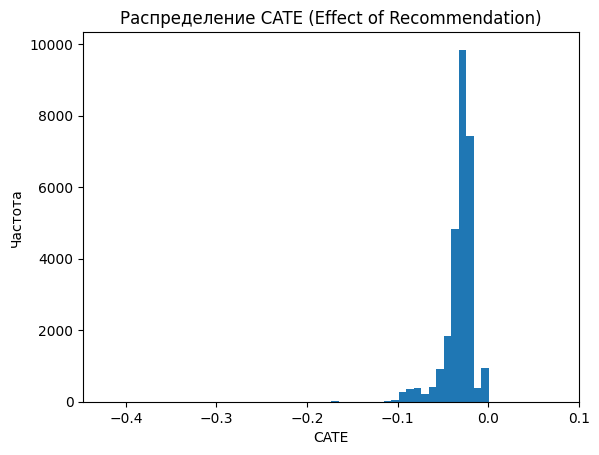

In [14]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# Определение фичей и целевых переменных
X = df[features]  # Все фичи, кроме ID и меток
T = df['is_recommended'].astype(int)  # Бинарный treatment (1 = рекомендовано, 0 = нет)
Y = df['label'].astype(int)          # Бинарный исход (например, покупка: 1/0)

# Добавляем treatment как фичу
X_slearner = X.copy()
X_slearner['is_recommended'] = T  # Важно: treatment становится частью фичей


# Разделение на train/test
X_train, X_test, T_train, T_test, y_train, Y_test = train_test_split(
    X_slearner, T, Y, test_size=0.2, random_state=42
)

# Обучение модели (например, градиентный бустинг)
model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Предсказание вероятностей для случаев "с рекомендацией" и "без"
X_test_t1 = X_test.copy()
X_test_t1['is_recommended'] = 1  # Все получают лечение

X_test_t0 = X_test.copy()
X_test_t0['is_recommended'] = 0  # Никто не получает лечение

prob_t1 = model.predict_proba(X_test_t1)[:, 1]  # P(y=1 | T=1, X)
prob_t0 = model.predict_proba(X_test_t0)[:, 1]  # P(y=1 | T=0, X)

# Расчет CATE (разница в вероятностях)
cate = prob_t1 - prob_t0

# 5. Анализ результатов
results = pd.DataFrame({
    'user_id': X_test.index,
    'item_id': df.loc[X_test.index, 'item_id'],
    'CATE': cate,
    'Treatment': T_test,
    'Actual_Outcome': Y_test
})

# Топ-5 товаров с максимальным CATE (наибольший uplift от рекомендации)
top_uplift = results.sort_values('CATE', ascending=False).head(5)
print("Топ-5 рекомендаций с максимальным Uplift:")
print(top_uplift)

# Визуализация распределения CATE
import matplotlib.pyplot as plt
plt.hist(cate, bins=60)
plt.title('Распределение CATE (Effect of Recommendation)')
plt.xlabel('CATE')
plt.ylabel('Частота')
plt.show()

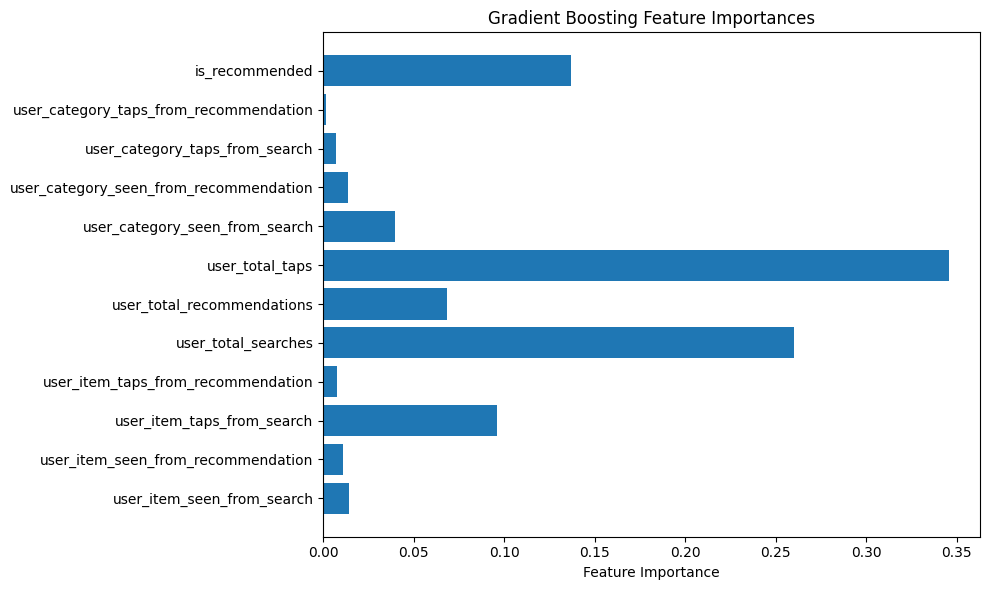

100%|===================| 111220/111654 [02:11<00:00]        

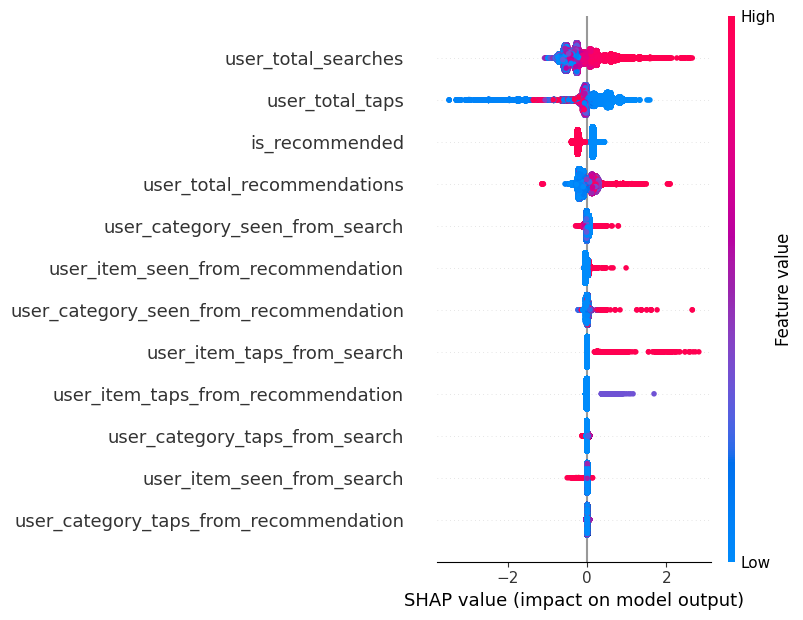

In [15]:
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier

# Assuming your model is already trained and stored in the variable `model`
# Also assuming you have your training data in `X_train`

# Plot traditional feature importances
importances = model.feature_importances_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Feature {i}" for i in range(X_train.shape[1])]
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Gradient Boosting Feature Importances")
plt.tight_layout()
plt.show()

# SHAP values
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_train)

# Summary plot
shap.summary_plot(shap_values, X_train)


In [39]:
Y_train.shape

(111654,)

In [45]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from econml.dr import DRLearner
from sklearn.calibration import CalibratedClassifierCV


# Определение фичей и целевых переменных
X = df[features]  # Все фичи, кроме ID и меток
T = df['is_recommended'].astype(int)  # Бинарный treatment (1 = рекомендовано, 0 = нет)
Y = df['label'].astype(int)          # Бинарный исход (например, покупка: 1/0)

# Разделение на train/test
X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
    X, T, Y, test_size=0.2, random_state=42
)

# 1. Оценка Propensity Score (модель для P(T=1|X))
propensity_model = CalibratedClassifierCV(
    GradientBoostingClassifier(n_estimators=100, max_depth=3)
)
propensity_model.fit(X_train, T_train)
propensity_scores = propensity_model.predict_proba(X_train)[:, 1]

# 2. Инициализация DR-Learner
dr_learner = DRLearner(
    model_regression=GradientBoostingRegressor(n_estimators=100),  # Модель для outcome
    model_propensity=GradientBoostingClassifier(n_estimators=100), # Модель для propensity (альтернатива)
    model_final=GradientBoostingRegressor(n_estimators=100),       # Финальная модель CATE
    cv=5                                                          # Кросс-валидация
)

# 3. Обучение DR-Learner
dr_learner.fit(Y_train, T_train, X=X_train)

# 4. Предсказание CATE для всех пользователей
cate = dr_learner.effect(X_test)


Топ-5 рекомендаций с максимальным Uplift:
        user_id  item_id      CATE  Treatment  Actual_Outcome
123085   123085   575055  2.622806          0               0
237945   237945  1114581  1.021642          1               0
467278   467278  1271395  0.931885          1               0
303085   303085    32290  0.870037          1               0
226432   226432   822957  0.554030          0               0


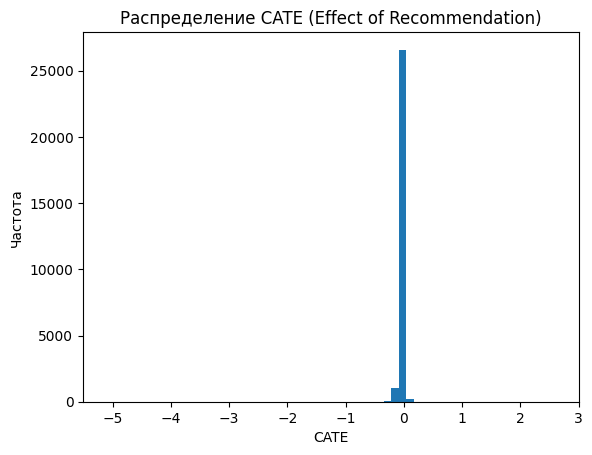

In [46]:
# 5. Анализ результатов
results = pd.DataFrame({
    'user_id': X_test.index,
    'item_id': df.loc[X_test.index, 'item_id'],
    'CATE': cate,
    'Treatment': T_test,
    'Actual_Outcome': Y_test
})

# Топ-5 товаров с максимальным CATE (наибольший uplift от рекомендации)
top_uplift = results.sort_values('CATE', ascending=False).head(5)
print("Топ-5 рекомендаций с максимальным Uplift:")
print(top_uplift)

# Визуализация распределения CATE
import matplotlib.pyplot as plt
plt.hist(cate, bins=60)
plt.title('Распределение CATE (Effect of Recommendation)')
plt.xlabel('CATE')
plt.ylabel('Частота')
plt.show()

## III. Персональные скидки

In [82]:
q = pd.read_csv('../../dunnhumby_transactions.csv')
q.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [84]:
q.COUPON_DISC.min()

-55.93

In [87]:
import pandas as pd
import numpy as np

# Загрузим датасет (предположим, он уже загружен в переменную df)
# df = pd.read_csv("dunnhumby.csv")

df = q.copy()
# Преобразуем WEEK_NO в удобную метрику
latest_week = df["WEEK_NO"].max()
target_weeks = [latest_week - 1, latest_week]  # последние 2 недели
history_weeks = df["WEEK_NO"] < latest_week - 1

# Создаем целевой датасет: покупки в последние 2 недели
df_target = df[df["WEEK_NO"].isin(target_weeks)]

# Позитивные примеры
positives = df_target.groupby(["household_key", "PRODUCT_ID"]).agg({
    "QUANTITY": "sum",
    "SALES_VALUE": "sum",
    "RETAIL_DISC": "sum",
    "COUPON_DISC": "mean"
}).reset_index()
positives["label"] = 1

# История до целевого периода
df_hist = df[df["WEEK_NO"] < latest_week - 1]

# Частота покупки товара пользователем до целевого периода
user_item_hist = df_hist.groupby(["household_key", "PRODUCT_ID"]).agg({
    "QUANTITY": ["sum", "count"],
    "SALES_VALUE": "sum",
    "RETAIL_DISC": "sum",
    "COUPON_DISC": "mean"
})
user_item_hist.columns = ['_'.join(col) for col in user_item_hist.columns]
user_item_hist = user_item_hist.reset_index()

# Пользователи и товары, которые были в истории, но не куплены в целевых неделях
# Эти примеры мы обозначим как негативные
positive_keys = set((u, i) for u, i in zip(positives.household_key, positives.PRODUCT_ID))
user_item_hist["label"] = user_item_hist.apply(
    lambda row: 0 if (row["household_key"], row["PRODUCT_ID"]) not in positive_keys else 1,
    axis=1
)

# Объединяем с позитивами (где label уже есть)
# Нужно быть уверенным, что не дублируем: уберем пересечения из исторических
negatives = user_item_hist[user_item_hist["label"] == 0]
positives = positives.merge(
    user_item_hist.drop(columns="label"),
    on=["household_key", "PRODUCT_ID"],
    how="left"
)

# Объединяем
final_df = pd.concat([positives, negatives], ignore_index=True)

# Заполним пропуски
final_df.fillna(0, inplace=True)

# Фичи
features = [
    "QUANTITY_sum", "QUANTITY_count", "SALES_VALUE_sum", 
    "RETAIL_DISC_sum", "COUPON_DISC_mean"
]

# Финальный вид
X = final_df[["household_key", "PRODUCT_ID"] + features]
y = final_df["label"]

print("Форма выборки:", X.shape)
print("Положительных примеров:", y.sum())
print("Отрицательных примеров:", (1 - y).sum())

Форма выборки: (1401469, 7)
Положительных примеров: 46190
Отрицательных примеров: 1355279


In [88]:
final_df.head()

,household_key,PRODUCT_ID,QUANTITY,SALES_VALUE,RETAIL_DISC,COUPON_DISC,label,QUANTITY_sum,QUANTITY_count,SALES_VALUE_sum,RETAIL_DISC_sum,COUPON_DISC_mean
0,1,820165,4.0,2.00,-0.67,0.0,1,7.0,2.0,3.50,0.00,0.00
1,1,830304,1.0,2.00,-1.89,0.0,1,0.0,0.0,0.00,0.00,0.00
2,1,835796,1.0,1.49,-0.89,-0.5,1,2.0,2.0,4.18,-1.08,-0.75
3,1,865900,1.0,2.89,0.00,0.0,1,0.0,0.0,0.00,0.00,0.00
4,1,898011,1.0,1.05,0.00,0.0,1,4.0,4.0,4.14,0.00,0.00


In [89]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# === Данные: X (features), y (label), как было подготовлено ранее ===
# Допустим, X содержит household_key и PRODUCT_ID — мы их исключим из фичей
id_cols = ["household_key", "PRODUCT_ID"]
feature_cols = [col for col in X.columns if col not in id_cols]

# === Трен/тест ===
X_train, X_val, y_train, y_val = train_test_split(
    X[feature_cols], y, test_size=0.2, random_state=42, stratify=y
)

# === Обучение модели ===
model = lgb.LGBMClassifier(random_state=42, n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

# === Валидация ===
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

print("ROC-AUC:", roc_auc_score(y_val, y_prob))
print(classification_report(y_val, y_pred))


[LightGBM] [Info] Number of positive: 36952, number of negative: 1084223
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027322 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1050
[LightGBM] [Info] Number of data points in the train set: 1121175, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032958 -> initscore=-3.378999
[LightGBM] [Info] Start training from score -3.378999
ROC-AUC: 0.8876426131046431
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    271056
           1       0.98      0.47      0.63      9238

    accuracy                           0.98    280294
   macro avg       0.98      0.73      0.81    280294
weighted avg       0.98      0.98      0.98    280294



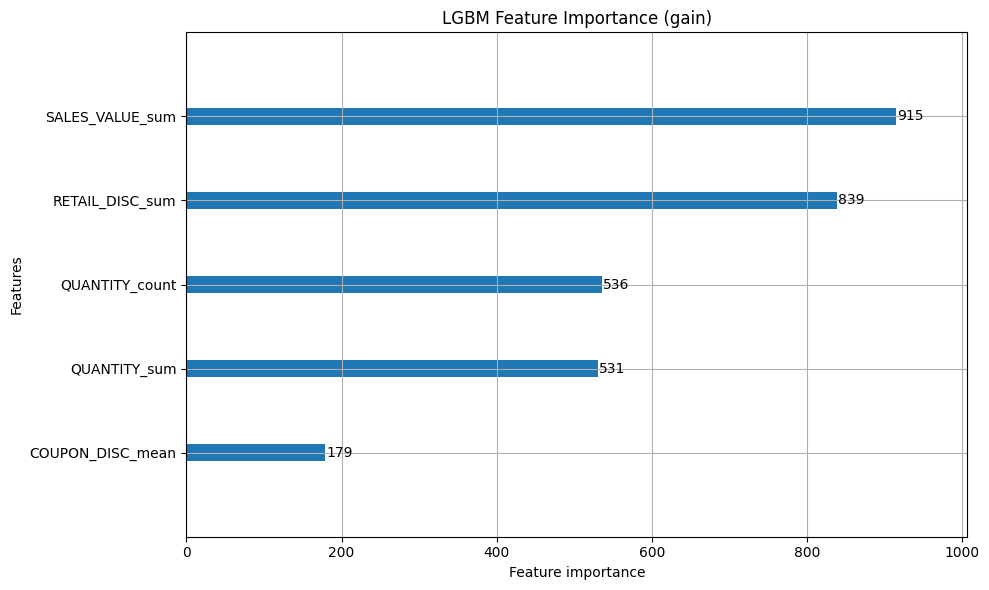

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


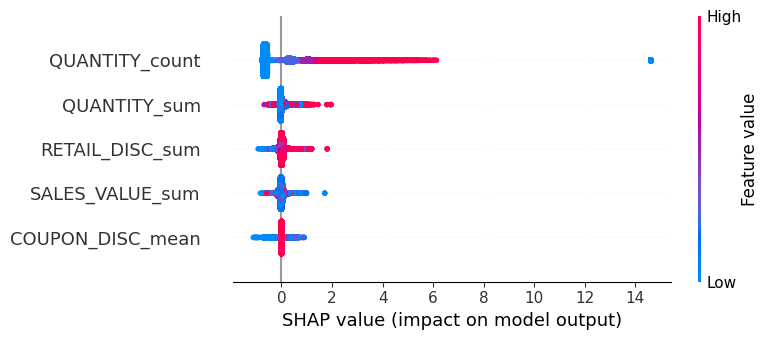

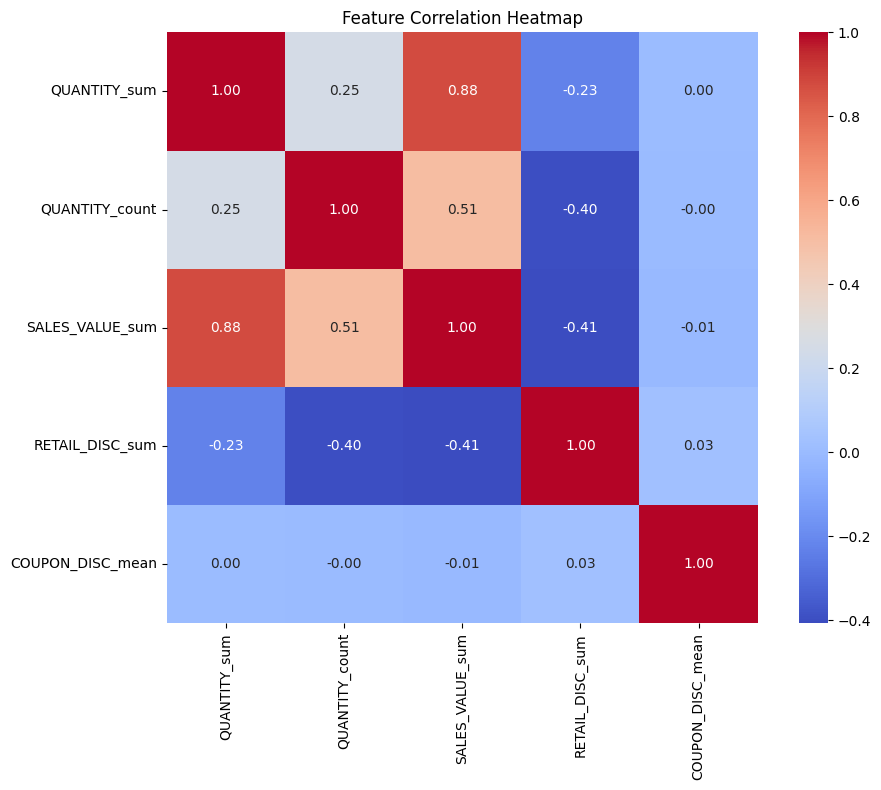

In [90]:

# === Feature Importance ===
lgb.plot_importance(model, max_num_features=20, importance_type='split', figsize=(10, 6))
plt.title("LGBM Feature Importance (gain)")
plt.tight_layout()
plt.show()

# === SHAP Values ===
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(shap_values[1], X_val, feature_names=feature_cols)

# === Корреляционная тепловая карта ===
plt.figure(figsize=(10, 8))
corr = X[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [91]:

# Выбираем уникальные user-item пары
# Можно взять, например, 100 случайных или популярных
user_items = X[["household_key", "PRODUCT_ID"] + feature_cols].drop_duplicates().sample(100, random_state=42)

# Создаём 10 уровней скидки от min до max
disc_bins = np.linspace(X["COUPON_DISC_mean"].min(), X["COUPON_DISC_mean"].max(), 10)

results = []

for _, row in user_items.iterrows():
    base_row = row.copy()
    preds = {"household_key": row["household_key"], "PRODUCT_ID": row["PRODUCT_ID"]}
    
    for i, disc in enumerate(disc_bins):
        test_row = base_row.copy()
        test_row["COUPON_DISC_mean"] = disc
        proba = model.predict_proba([test_row[feature_cols]])[0][1]
        preds[f"pred_disc_{i+1}"] = proba
    
    results.append(preds)

df_disc_effect = pd.DataFrame(results)

# Посмотрим на результат
df_disc_effect.head()

,household_key,PRODUCT_ID,pred_disc_1,pred_disc_2,pred_disc_3,pred_disc_4,pred_disc_5,pred_disc_6,pred_disc_7,pred_disc_8,pred_disc_9,pred_disc_10
0,489.0,1023726.0,0.002084,0.002084,0.002084,0.002084,0.002084,0.002084,0.002084,0.002975,0.002975,0.006235
1,1145.0,996402.0,0.001927,0.001927,0.001927,0.001927,0.001927,0.001927,0.001927,0.002751,0.002751,0.006283
2,1335.0,1031447.0,0.001776,0.001776,0.001776,0.001776,0.001776,0.001776,0.001776,0.002536,0.002536,0.004885
3,591.0,935393.0,0.001746,0.001746,0.001746,0.001746,0.001746,0.001746,0.001746,0.002257,0.002257,0.005493
4,2479.0,9242918.0,0.006806,0.006806,0.006806,0.006806,0.006806,0.006806,0.006806,0.009708,0.009708,0.019907


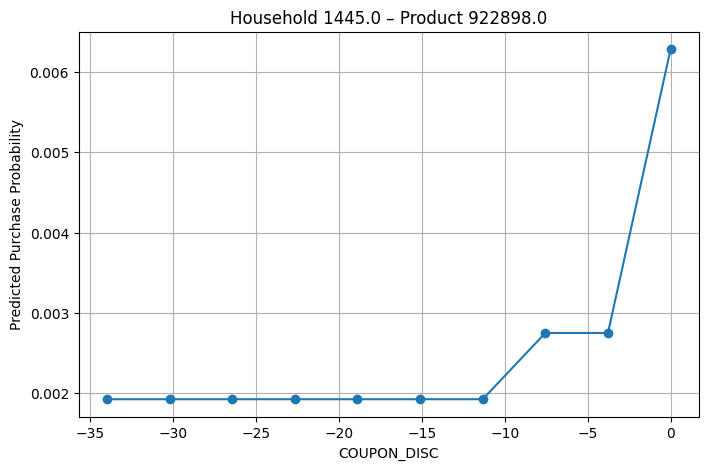

In [94]:
# Построим график изменения вероятности от скидки для первого user-item
row = df_disc_effect.iloc[10]
disc_vals = [row[f"pred_disc_{i}"] for i in range(1, 11)]

plt.figure(figsize=(8, 5))
plt.plot(disc_bins, disc_vals, marker='o')
plt.title(f"Household {row['household_key']} – Product {row['PRODUCT_ID']}")
plt.xlabel("COUPON_DISC")
plt.ylabel("Predicted Purchase Probability")
plt.grid(True)
plt.show()


## Монотонные ограничения

In [110]:
from lightgbm import LGBMClassifier

# Получаем индекс фичи COUPON_DISC_sum
monotone_constraints = []
for col in feature_cols:
    if col == "COUPON_DISC_mean":
        monotone_constraints.append(-1)  # чем меньше купон, тем выше вероятность
    else:
        monotone_constraints.append(0)   # остальные фичи без ограничений

# Обучаем модель с учетом ограничений
model = LGBMClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    monotone_constraints=monotone_constraints
)

model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 36952, number of negative: 1084223
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030600 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1050
[LightGBM] [Info] Number of data points in the train set: 1121175, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032958 -> initscore=-3.378999
[LightGBM] [Info] Start training from score -3.378999


LGBMClassifier(monotone_constraints=[0, 0, 0, 0, -1], random_state=42)

In [116]:
X["COUPON_DISC_mean"].value_counts().head(30)

COUPON_DISC_mean
 0.000000    1373948
-1.000000       5194
-0.500000       3976
-0.250000       1586
-0.750000       1566
-0.550000       1403
-0.400000        852
-0.350000        812
-2.000000        750
-1.500000        503
-0.333333        473
-0.200000        425
-0.166667        412
-2.500000        394
-0.125000        389
-0.300000        354
-0.375000        350
-0.275000        332
-1.250000        263
-3.000000        213
-0.600000        212
-0.175000        199
-0.100000        194
-0.083333        162
-0.183333        148
-0.150000        145
-0.666667        113
-0.625000        111
-0.833333        108
-0.450000        104
Name: count, dtype: int64

In [117]:

# Выбираем уникальные user-item пары
# Можно взять, например, 100 случайных или популярных
user_items = X[["household_key", "PRODUCT_ID"] + feature_cols].drop_duplicates().sample(100, random_state=42)

# Создаём 10 уровней скидки от min до max
disc_bins = np.linspace(-1.5, 0, 20)

results = []

for _, row in user_items.iterrows():
    base_row = row.copy()
    preds = {"household_key": row["household_key"], "PRODUCT_ID": row["PRODUCT_ID"]}
    
    for i, disc in enumerate(disc_bins):
        test_row = base_row.copy()
        test_row["COUPON_DISC_mean"] = disc
        proba = model.predict_proba([test_row[feature_cols]])[0][1]
        preds[f"pred_disc_{i+1}"] = proba
    
    results.append(preds)

df_disc_effect = pd.DataFrame(results)

# Посмотрим на результат
df_disc_effect.head()

,household_key,PRODUCT_ID,pred_disc_1,pred_disc_2,pred_disc_3,pred_disc_4,pred_disc_5,pred_disc_6,pred_disc_7,pred_disc_8,...,pred_disc_11,pred_disc_12,pred_disc_13,pred_disc_14,pred_disc_15,pred_disc_16,pred_disc_17,pred_disc_18,pred_disc_19,pred_disc_20
0,489.0,1023726.0,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,...,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224
1,1145.0,996402.0,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,...,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267
2,1335.0,1031447.0,0.004835,0.004835,0.004835,0.004835,0.004835,0.004835,0.004835,0.004835,...,0.004835,0.004835,0.004835,0.004835,0.004835,0.004835,0.004835,0.004835,0.004835,0.004835
3,591.0,935393.0,0.005440,0.005440,0.005440,0.005440,0.005440,0.005440,0.005440,0.005440,...,0.005440,0.005440,0.005440,0.005440,0.005440,0.005440,0.005440,0.005440,0.005440,0.005440
4,2479.0,9242918.0,0.020930,0.020930,0.020930,0.020930,0.019884,0.019884,0.019884,0.019884,...,0.019884,0.019884,0.019884,0.019884,0.019884,0.019884,0.019884,0.019884,0.019884,0.019884


In [118]:
df_disc_effect['diff'] = df_disc_effect['pred_disc_1'] - df_disc_effect['pred_disc_10']
df_disc_effect.sort_values(by='diff')

,household_key,PRODUCT_ID,pred_disc_1,pred_disc_2,pred_disc_3,pred_disc_4,pred_disc_5,pred_disc_6,pred_disc_7,pred_disc_8,...,pred_disc_12,pred_disc_13,pred_disc_14,pred_disc_15,pred_disc_16,pred_disc_17,pred_disc_18,pred_disc_19,pred_disc_20,diff
0,489.0,1023726.0,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,...,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.000000
68,1728.0,999581.0,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,...,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.006224,0.000000
67,1940.0,8119128.0,0.006808,0.006808,0.006808,0.006808,0.006808,0.006808,0.006808,0.006808,...,0.006808,0.006808,0.006808,0.006808,0.006808,0.006808,0.006808,0.006808,0.006808,0.000000
66,1778.0,978497.0,0.006065,0.006065,0.006065,0.006065,0.006065,0.006065,0.006065,0.006065,...,0.006065,0.006065,0.006065,0.006065,0.006065,0.006065,0.006065,0.006065,0.006065,0.000000
64,2154.0,820518.0,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,...,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,0.006267,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,1840.0,12171812.0,0.011160,0.007185,0.007185,0.007185,0.007185,0.007185,0.007185,0.007185,...,0.007185,0.007185,0.007185,0.007185,0.007185,0.007185,0.007185,0.007185,0.007185,0.003975
46,2275.0,947220.0,0.011160,0.007185,0.007185,0.007185,0.007185,0.007185,0.007185,0.007185,...,0.007185,0.007185,0.007185,0.007185,0.007185,0.007185,0.007185,0.007185,0.007185,0.003975
43,1092.0,1123420.0,0.014298,0.009216,0.009216,0.009216,0.009216,0.009216,0.009216,0.009216,...,0.009216,0.009216,0.007651,0.007651,0.007651,0.007651,0.007651,0.007651,0.007651,0.005082
85,2086.0,834488.0,0.021013,0.013577,0.013577,0.013577,0.013577,0.013577,0.013577,0.013577,...,0.013577,0.013577,0.011280,0.011280,0.011280,0.011280,0.011280,0.011280,0.011280,0.007436
